Hello world program-This example contains two parts. You will first create a simple quantum program and run it on a quantum processing unit (QPU). Because actual quantum research requires much more robust programs, in the second section (Scale to large numbers of qubits), you will scale the simple program up to utility level.

https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world

Install and authenticate # Install Qiskit Runtime to run jobs on quantum hardware:

In [1]:
#Install Qiskit Runtime to run jobs on quantum hardware
!pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 7.1 MB/s eta 0:00:00


In [2]:
#Set up an environment to run Jupyter notebooks locally:
!pip install jupyter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.9 MB/s eta 0:00:00


Set up your authentication for access to quantum hardware through the free Open Plan.

(If you were emailed an invitation to join an account, follow the steps for invited users instead.)

Go to IBM Quantum Platform to log in or create an account.

Generate your API key (also called an API token) on the dashboard, then copy it to a secure location.

Go to the Instances page and find the instance you want to use. Hover over its CRN and click to copy it.

Save your credentials locally with this code:

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
token="Paste_Your_API_KEY", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="Paster_your_CRN", # Optional
overwrite=True
)

Now you can use this Python code any time you want to authenticate to the Qiskit Runtime Service:

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()

Create and run a simple quantum program
The four steps to writing a quantum program using Qiskit patterns are:

Map the problem to a quantum-native format.

Optimize the circuits and operators.

Execute using a quantum primitive function.

Analyze the results.

Step 1. Map the problem to a quantum-native format
In a quantum program, quantum circuits are the native format in which to represent quantum instructions, and operators represent the observables to be measured. When creating a circuit, you'll usually create a new QuantumCircuit object, then add instructions to it in sequence.

The following code cell creates a circuit that produces a Bell state, which is a state wherein two qubits are fully entangled with each other.

Note: bit ordering
The Qiskit SDK uses the LSb 0 bit numbering where the
n
t
h
n
th
  digit has value
1
≪
n
1≪n or
2
n
2
n
 . For more details, see the Bit-ordering in the Qiskit SDK topic.

In [6]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2de285e54690f824facf9505c0fe9f0b6eb7213f55e19683dabc459ad7ab761f
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [7]:
!pip install matplotlib

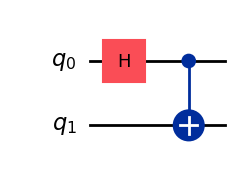

In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

See QuantumCircuit in the documentation for all available operations.

When creating quantum circuits, you must also consider what type of data you want returned after execution. Qiskit provides two ways to return data: you can obtain a probability distribution for a set of qubits you choose to measure, or you can obtain the expectation value of an observable. Prepare your workload to measure your circuit in one of these two ways with Qiskit primitives (explained in detail in Step 3).

This example measures expectation values by using the qiskit.quantum_info submodule, which is specified by using operators (mathematical objects used to represent an action or process that changes a quantum state). The following code cell creates six two-qubit Pauli operators: IZ, IX, ZI, XI, ZZ, and XX.

In [9]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

Here, something like the ZZ operator is a shorthand for the tensor product
Z
⊗
Z
Z⊗Z, which means measuring Z on qubit 1 and Z on qubit 0 together, and obtaining information about the correlation between qubit 1 and qubit 0. Expectation values like this are also typically written as
⟨
Z
1
Z
0
⟩
⟨Z
1
​
 Z
0
​
 ⟩.

If the state is entangled, then the measurement of
⟨
Z
1
Z
0
⟩
⟨Z
1
​
 Z
0
​
 ⟩ should be different from the measurement of
⟨
I
1
⊗
Z
0
⟩
⟨
Z
1
⊗
I
0
⟩
⟨I
1
​
 ⊗Z
0
​
 ⟩⟨Z
1
​
 ⊗I
0
​
 ⟩. For the specific entangled state created by our circuit described above, the measurement of
⟨
Z
1
Z
0
⟩
⟨Z
1
​
 Z
0
​
 ⟩ should be 1 and the measurement of
⟨
I
1
⊗
Z
0
⟩
⟨
Z
1
⊗
I
0
⟩
⟨I
1
​
 ⊗Z
0
​
 ⟩⟨Z
1
​
 ⊗I
0
​
 ⟩ should be zero.

Step 2. Optimize the circuits and operators
When executing circuits on a device, it is important to optimize the set of instructions that the circuit contains and minimize the overall depth (roughly the number of instructions) of the circuit. This ensures that you obtain the best results possible by reducing the effects of error and noise. Additionally, the circuit's instructions must conform to a backend device's Instruction Set Architecture (ISA) and must consider the device's basis gates and qubit connectivity.

The following code instantiates a real device to submit a job to and transforms the circuit and observables to match that backend's ISA. It requires that you have already saved your credentia

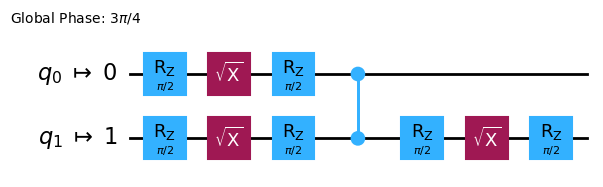

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

Step 3. Execute using the quantum primitives
Quantum computers can produce random results, so you usually collect a sample of the outputs by running the circuit many times. You can estimate the value of the observable by using the Estimator class. Estimator is one of two primitives; the other is Sampler, which can be used to get data from a quantum computer. These objects possess a run() method that executes the selection of circuits, observables, and parameters (if applicable), using a primitive unified bloc (PUB).

In [11]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d6kh4jpv66hs738adagg


After a job is submitted, you can wait until either the job is completed within your current python instance, or use the job_id to retrieve the data at a later time. (See the section on retrieving jobs for details.)

After the job completes, examine its output through the job's result() attribute.

In [12]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

Step 4. Analyze the results
The analyze step is typically where you might post-process your results using, for example, measurement error mitigation or zero noise extrapolation (ZNE). You might feed these results into another workflow for further analysis or prepare a plot of the key values and data. In general, this step is specific to your problem. For this example, plot each of the expectation values that were measured for our circuit.

The expectation values and standard deviations for the observables you specified to Estimator are accessed through the job result's PubResult.data.evs and PubResult.data.stds attributes. To obtain the results from Sampler, use the PubResult.data.meas.get_counts() function, which will return a dict of measurements in the form of bitstrings as keys and counts as their corresponding values. For more information, see Get started with Sampler.

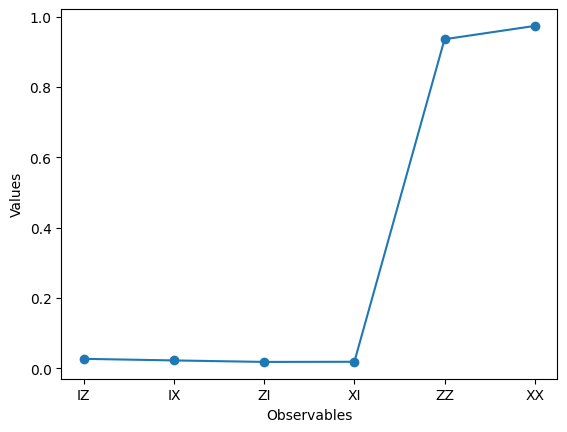

In [13]:
# Plot the result

from matplotlib import pyplot as plt

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

Notice that for qubits 0 and 1, the independent expectation values of both X and Z are 0, while the correlations (XX and ZZ) are 1. This is a hallmark of quantum entanglement.

When you run your quantum program on a real device, your workload must wait in a queue before it runs. To save time, you can instead use the following code to run this small workload on the fake_provider with the Qiskit Runtime local testing mode. Note that this is only possible for a small circuit. When you scale up in the next section, you will need to use a real device.

In [14]:

# Use the following code instead if you want to run on a simulator:

from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)

# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()

# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).

job_result = job.result()

# This is the result from our single pub, which had five observables,
# so contains information on all five.

pub_result = job.result()[0]

Step 4. Analyze the results
The analyze step is typically where you might post-process your results using, for example, measurement error mitigation or zero noise extrapolation (ZNE). You might feed these results into another workflow for further analysis or prepare a plot of the key values and data. In general, this step is specific to your problem. For this example, plot each of the expectation values that were measured for our circuit.

The expectation values and standard deviations for the observables you specified to Estimator are accessed through the job result's PubResult.data.evs and PubResult.data.stds attributes. To obtain the results from Sampler, use the PubResult.data.meas.get_counts() function, which will return a dict of measurements in the form of bitstrings as keys and counts as their corresponding values. For more information, see Get started with Sampler.

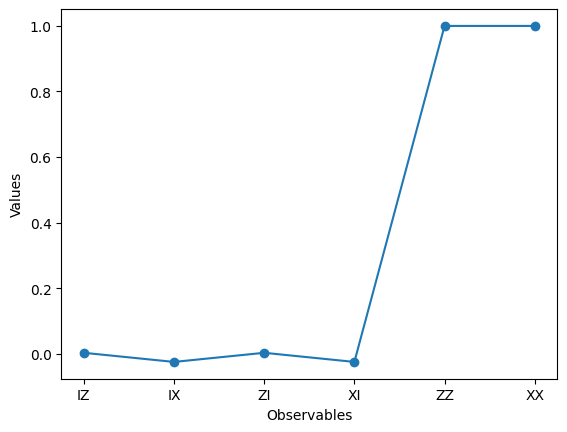

In [15]:
# Plot the result

from matplotlib import pyplot as plt

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

Notice that for qubits 0 and 1, the independent expectation values of both X and Z are 0, while the correlations (XX and ZZ) are 1. This is a hallmark of quantum entanglement.

Scale to large numbers of qubits

In quantum computing, utility-scale work is crucial for making progress in the field. Such work requires computations to be done on a much larger scale; working with circuits that might use over 100 qubits and over 1000 gates. This example demonstrates how you can accomplish utility-scale work on IBM® QPUs by creating and analyzing a 100-qubit GHZ state. It uses the Qiskit patterns workflow and ends by measuring the expectation value
⟨
Z
0
Z
i
⟩
⟨Z
0
​
 Z
i
​
 ⟩ for each qubit.

Step 1. Map the problem
Write a function that returns a QuantumCircuit that prepares an
n
n-qubit GHZ state (essentially an extended Bell state), then use that function to prepare a 100-qubit GHZ state and collect the observables to be measured.

In [16]:
from qiskit import QuantumCircuit


def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc) for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state, assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with two qubits (first argument) and two classical
# bits (second argument)
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)

Next, map to the operators of interest. This example uses the ZZ operators between qubits to examine the behavior as they get farther apart. Increasingly inaccurate (corrupted) expectation values between distant qubits would reveal the level of noise present.

In [17]:
from qiskit.quantum_info import SparsePauliOp

# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + "I" * i + "Z" + "I" * (n - 2 - i) for i in range(n - 1)
]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator) for operator in operator_strings]

['ZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

Step 2. Optimize the problem for execution on quantum hardware
The following code transforms the circuit and observables to match the backend's ISA. It requires that you have already saved your credentials

In [18]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

isa_circuit = pm.run(qc)
isa_operators_list = [op.apply_layout(isa_circuit.layout) for op in operators]

Step 3. Execute on hardware
Submit the job and enable error suppression by using a technique to reduce errors called dynamical decoupling. The resilience level specifies how much resilience to build against errors. Higher levels generate more accurate results, at the expense of longer processing times. For further explanation of the options set in the following code, see Configure error mitigation for Qiskit Runtime.

In [19]:
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator

options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

# Create an Estimator object
estimator = Estimator(backend, options=options)

In [20]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()
print(job_id)

d6kh5dhfopvc73f3mkm0


Step 4. Post-process results
After the job completes, plot the results and notice that
⟨
Z
0
Z
i
⟩
⟨Z
0
​
 Z
i
​
 ⟩ decreases with increasing
i
i, even though in an ideal simulation all
⟨
Z
0
Z
i
⟩
⟨Z
0
​
 Z
i
​
 ⟩ should be 1.

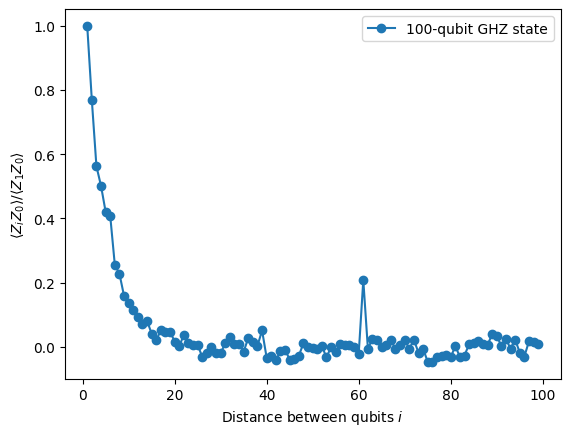

In [21]:
import matplotlib.pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService

# data
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

# plotting graph
plt.plot(data, values, marker="o", label="100-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

The previous plot shows that as the distance between qubits increases, the signal decays because of the presence of noise.

In [22]:
!pip install qiskit matplotlib qiskit[visualization]

# On a zsh terminal, use this line instead:
# pip install qiskit matplotlib 'qiskit[visualization]'

In [23]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(1, 2)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'000': 521, '001': 503}


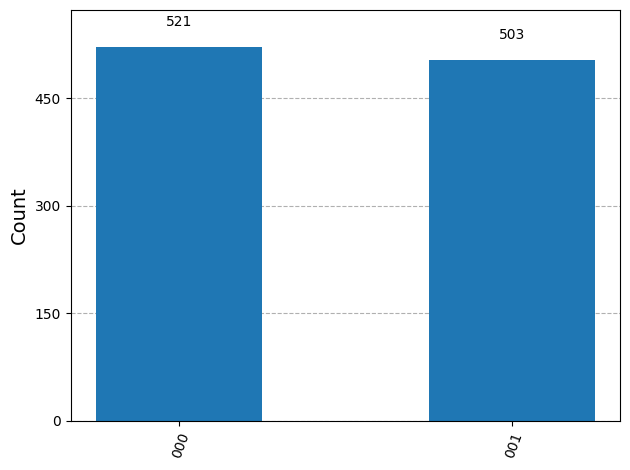

In [24]:
from qiskit.visualization import plot_histogram

counts = result[0].data.meas.get_counts()
plot_histogram(counts)

# Include the next line if you are not using Python in a Jupyter notebook
# plt.show()